# RLHF (DPO + PPO-RLHF)
This notebook trains DPO and PPO-RLHF from preference datasets produced in the previous step.

Notes:
- Change `ENV_KEY` to switch environments (e.g., `cartpole`, `pendulum`).
- Dataset sizes K are inferred from pickle filenames (e.g., `_K50.pkl`).

In [120]:
from __future__ import annotations

import re
import pickle
import copy
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.ppo.policies import MlpPolicy
from tqdm.auto import tqdm

In [ ]:
ENV_KEY = "pendulum"  # change to: cartpole | pendulum
ENV_ID_MAP = {"cartpole": "CartPole-v1", "pendulum": "Pendulum-v1"}
ENV_ID = ENV_ID_MAP.get(ENV_KEY, ENV_KEY)
temp_env = gym.make(ENV_ID)
ENV_CONTINUOUS = isinstance(temp_env.action_space, gym.spaces.Box)
ENV_OBS_DIM = temp_env.observation_space.shape[0]
ENV_ACTION_DIM = temp_env.action_space.shape[0] if ENV_CONTINUOUS else temp_env.action_space.n

DATASET_ROOT = Path("outputs/datasets")
OUTPUT_DIR = Path("outputs/part3")
CHECKPOINT_DIR = Path("outputs/checkpoints")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# DPO config
DPO_BETA = 0.1
DPO_EPOCHS = 5
DPO_BATCH_SIZE = 16
DPO_LR = 1e-4
DPO_CHECKPOINT_STEPS = 1024*16

# Reward model config
RM_EPOCHS = 500
RM_BATCH_SIZE = 16
RM_LR = 1e-3

# PPO-RLHF config
PPO_TIMESTEPS = 1_000_000
PPO_CHECKPOINT_STEPS = 1024
PPO_LR = 3e-4
PPO_N_STEPS = 1024
PPO_BATCH_SIZE = 64
PPO_GAMMA = 0.99

# Early stopping
TARGET_TRUE_REWARD = -200 # -200 for pendulum, 490 for cartpole

# Evaluation
EVAL_EPISODES = 20

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


## Dataset discovery + normalization

In [122]:
K_REGEX = re.compile(r"_K(\d+)", re.IGNORECASE)
SEED_REGEX = re.compile(r"seed(\d+)", re.IGNORECASE)


@dataclass
class PreferenceDataset:
    env_key: str
    k: int
    seed: int
    path: Path
    s_pref_list: List[np.ndarray]
    a_pref_list: List[np.ndarray]
    s_rej_list: List[np.ndarray]
    a_rej_list: List[np.ndarray]


def load_preference_datasets(env_key: str) -> List[PreferenceDataset]:
    pattern = f"{env_key.lower()}_seed*_K*.pkl"
    paths = sorted(DATASET_ROOT.glob(pattern))
    paths = [p for p in paths if "_old" not in p.name]
    datasets: List[PreferenceDataset] = []
    for path in paths:
        m_k = K_REGEX.search(path.name)
        if not m_k:
            continue
        m_seed = SEED_REGEX.search(path.name)
        if not m_seed:
            raise ValueError(f"Missing seed in dataset filename: {path.name}")
        k = int(m_k.group(1))
        seed = int(m_seed.group(1))
        with open(path, "rb") as f:
            raw_pairs = pickle.load(f)
        s_pref_list: List[np.ndarray] = []
        a_pref_list: List[np.ndarray] = []
        s_rej_list: List[np.ndarray] = []
        a_rej_list: List[np.ndarray] = []
        for pair in raw_pairs:
            tau1 = pair["tau_1"]
            tau2 = pair["tau_2"]
            states1 = np.asarray([step[0] for step in tau1])
            actions1 = np.asarray([step[1] for step in tau1])
            states2 = np.asarray([step[0] for step in tau2])
            actions2 = np.asarray([step[1] for step in tau2])
            label = int(pair["label"])
            if label == 0:
                s_pref, a_pref = states1, actions1
                s_rej, a_rej = states2, actions2
            else:
                s_pref, a_pref = states2, actions2
                s_rej, a_rej = states1, actions1
            s_pref_list.append(s_pref)
            a_pref_list.append(a_pref)
            s_rej_list.append(s_rej)
            a_rej_list.append(a_rej)
        datasets.append(
            PreferenceDataset(
                env_key=env_key,
                k=k,
                seed=seed,
                path=path,
                s_pref_list=s_pref_list,
                a_pref_list=a_pref_list,
                s_rej_list=s_rej_list,
                a_rej_list=a_rej_list,
            )
        )
    return datasets


dataset_list = load_preference_datasets(ENV_KEY)
print(f"Loaded {len(dataset_list)} datasets for env {ENV_KEY}")


Loaded 6 datasets for env pendulum


## Loading policies

In [123]:
POLICY_SEED = 0

p1_path = CHECKPOINT_DIR / f"pi1_{ENV_KEY}_seed{POLICY_SEED}.zip"
p2_path = CHECKPOINT_DIR / f"pi2_{ENV_KEY}_seed{POLICY_SEED}.zip"
if not p1_path.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {p1_path}")
if not p2_path.exists():
    raise FileNotFoundError(f"Missing policy checkpoint: {p2_path}")

p1_policy = PPO.load(p1_path, device=DEVICE).policy
p2_policy = PPO.load(p2_path, device=DEVICE).policy
print(f"Loaded policies for {ENV_KEY} from {p1_path} and {p2_path}")

Loaded policies for pendulum from outputs/checkpoints/pi1_pendulum_seed0.zip and outputs/checkpoints/pi2_pendulum_seed0.zip


## DPO (offline policy optimization from preferences)

In [124]:
def trajectory_logprob(policy: MlpPolicy, states: np.ndarray, actions: np.ndarray) -> torch.Tensor:
    states_t = torch.tensor(states, dtype=torch.float32, device=DEVICE)

    distribution = policy.get_distribution(states_t)

    if isinstance(temp_env.action_space, gym.spaces.Discrete):
        actions_t = torch.tensor(actions, dtype=torch.long, device=DEVICE)
    else:
        actions_t = torch.tensor(actions, dtype=torch.float32, device=DEVICE)

    logp = distribution.log_prob(actions_t)

    return logp.sum()


def dpo_loss(
    policy: MlpPolicy,
    ref_policy: MlpPolicy,
    s_pref: np.ndarray,
    a_pref: np.ndarray,
    s_rej: np.ndarray,
    a_rej: np.ndarray,
    beta: float,
) -> torch.Tensor:
    logp_pref = trajectory_logprob(policy, s_pref, a_pref)
    logp_rej = trajectory_logprob(policy, s_rej, a_rej)
    logp_ref_pref = trajectory_logprob(ref_policy, s_pref, a_pref)
    logp_ref_rej = trajectory_logprob(ref_policy, s_rej, a_rej)
    adv = (logp_pref - logp_rej) - (logp_ref_pref - logp_ref_rej)
    logits = beta * adv
    labels = torch.ones_like(logits)
    return F.binary_cross_entropy_with_logits(logits, labels)


def make_env(env_id: str, seed: int) -> gym.Env:
    env = gym.make(env_id)
    env.reset(seed=seed)
    env = Monitor(env)
    return env


def eval_policy_true_reward(
    model: MlpPolicy,
    env_id: str,
    episodes: int,
    eval_seed: int,
) -> Tuple[float, float]:
    rng = np.random.default_rng(eval_seed)
    env = DummyVecEnv([lambda: make_env(env_id, seed=int(rng.integers(0, 1000000))) for _ in range(episodes)])
    mean, std = evaluate_policy(model, env, n_eval_episodes=episodes, deterministic=True)
    env.close()
    return float(mean), float(std)


def train_dpo(
    s_pref_list: List[np.ndarray],
    a_pref_list: List[np.ndarray],
    s_rej_list: List[np.ndarray],
    a_rej_list: List[np.ndarray],
    eval_seed: int,
    epochs: int = DPO_EPOCHS,
    batch_size: int = DPO_BATCH_SIZE,
    lr: float = DPO_LR,
    beta: float = DPO_BETA,
    log_every: int = 1,
) -> Tuple[MlpPolicy, Dict[str, List[float]]]:
    policy = copy.deepcopy(p2_policy).to(DEVICE)
    ref_policy = copy.deepcopy(p2_policy).to(DEVICE)
    ref_policy.eval()
    # Explicitly freeze the reference policy
    for param in ref_policy.parameters():
        param.requires_grad = False
    optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
    n = len(s_pref_list)
    history: Dict[str, List[float]] = {
        "steps": [],
        "mean_reward": [],
        "std_reward": [],
        "dpo_losses": [],
        "dpo_loss_steps": [],
    }
    processed_steps = 0
    next_checkpoint = DPO_CHECKPOINT_STEPS
    stopped_early = False

    def record_checkpoint(step_count: int) -> bool:
        nonlocal stopped_early
        was_training = policy.training
        policy.eval()
        mean_reward, std_reward = eval_policy_true_reward(
            policy,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        history["steps"].append(step_count)
        history["mean_reward"].append(mean_reward)
        history["std_reward"].append(std_reward)
        checkpoint_idx = len(history["steps"])
        if log_every <= 1 or checkpoint_idx % log_every == 1:
            print(
                f"DPO checkpoint at step {step_count}: true reward {mean_reward:.3f} ± {std_reward:.3f}"
            )
        if mean_reward >= TARGET_TRUE_REWARD:
            print(
                f"DPO early stopping at step {step_count}: true reward {mean_reward:.3f} ",
                f">= target {TARGET_TRUE_REWARD:.3f}"
            )
            stopped_early = True
        if was_training:
            policy.train()
        return stopped_early

    for epoch in tqdm(range(epochs), desc="DPO training", unit="epoch"):
        if stopped_early:
            break
        idx = np.random.permutation(n)
        batch_iter = tqdm(
            range(0, n, batch_size),
            desc=f"DPO epoch {epoch + 1}/{epochs}",
            unit="batch",
            leave=False,
        )
        for start in batch_iter:
            if stopped_early:
                break
            batch_idx = idx[start:start + batch_size]
            losses = []
            batch_steps = 0
            for i in batch_idx:
                loss = dpo_loss(
                    policy,
                    ref_policy,
                    s_pref_list[i],
                    a_pref_list[i],
                    s_rej_list[i],
                    a_rej_list[i],
                    beta,
                )
                losses.append(loss)
                batch_steps += len(s_pref_list[i]) + len(s_rej_list[i])
            if not losses:
                continue
            batch_loss = torch.stack(losses).mean()
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()
            processed_steps += batch_steps
            # record DPO batch loss and the corresponding processed step
            try:
                history["dpo_losses"].append(float(batch_loss.item()))
                history["dpo_loss_steps"].append(processed_steps)
            except Exception:
                pass
            while processed_steps >= next_checkpoint and not stopped_early:
                if record_checkpoint(processed_steps):
                    break
                next_checkpoint += DPO_CHECKPOINT_STEPS
    if not history["steps"] or (history["steps"][-1] != processed_steps and not stopped_early):
        record_checkpoint(processed_steps)
    return policy, history

## PPO-RLHF (reward model + PPO)

In [125]:
class RewardModel(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, continuous: bool, hidden: int = 64):
        super().__init__()
        self.continuous = continuous
        in_dim = obs_dim + action_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
        self.action_dim = action_dim
        # centering offset: subtracted in forward so PPO sees rewards near zero
        self.register_buffer('bias', torch.zeros(1))

    def forward(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        if self.continuous:
            act_feat = act
        else:
            act_feat = F.one_hot(act, num_classes=self.action_dim).float()
        x = torch.cat([obs, act_feat], dim=-1)
        return self.net(x).squeeze(-1) - self.bias

    def trajectory_return(self, states: torch.Tensor, actions: torch.Tensor) -> torch.Tensor:
        rewards = self.forward(states, actions)
        return rewards.sum()


def reward_model_loss(
    model: RewardModel,
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
    labels: List[int],
    lambda_reg: float = 0.0,
) -> Tuple[torch.Tensor, torch.Tensor]:
    B = len(s1_list)
    T = s1_list[0].shape[0]  # uniform trajectory length (always 200 for Pendulum)

    s1_t = torch.tensor(np.stack(s1_list), dtype=torch.float32, device=DEVICE).view(B * T, -1)
    s2_t = torch.tensor(np.stack(s2_list), dtype=torch.float32, device=DEVICE).view(B * T, -1)
    if model.continuous:
        a1_t = torch.tensor(np.stack(a1_list), dtype=torch.float32, device=DEVICE).view(B * T, -1)
        a2_t = torch.tensor(np.stack(a2_list), dtype=torch.float32, device=DEVICE).view(B * T, -1)
    else:
        a1_t = torch.tensor(np.stack(a1_list), dtype=torch.long, device=DEVICE).view(B * T)
        a2_t = torch.tensor(np.stack(a2_list), dtype=torch.long, device=DEVICE).view(B * T)

    r1_flat = model.forward(s1_t, a1_t)  # (B*T,)
    r2_flat = model.forward(s2_t, a2_t)  # (B*T,)

    logits_t = r1_flat.view(B, T).sum(dim=1) - r2_flat.view(B, T).sum(dim=1)  # (B,)
    labels_t = torch.tensor(labels, dtype=torch.float32, device=DEVICE)

    loss = F.binary_cross_entropy_with_logits(logits_t, labels_t)
    # variance penalty — penalizes spread, not absolute magnitude; consistent with post-training centering
    if lambda_reg > 0.0:
        all_steps = torch.cat([r1_flat, r2_flat])
        loss = loss + lambda_reg * all_steps.var()

    preds = (torch.sigmoid(logits_t) >= 0.5).float()
    acc = (preds == labels_t).float().mean()
    return loss, acc


def eval_reward_model(
    model: RewardModel,
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
    chunk: int = 512,
) -> Tuple[float, float]:
    if not s1_list:
        return float("nan"), float("nan")
    n = len(s1_list)
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for start in range(0, n, chunk):
            end = min(start + chunk, n)
            w = end - start
            loss, acc = reward_model_loss(
                model,
                s1_list[start:end], a1_list[start:end],
                s2_list[start:end], a2_list[start:end],
                [1] * w,
            )
            total_loss += float(loss.item()) * w
            total_acc += float(acc.item()) * w
            total_n += w
    return total_loss / total_n, total_acc / total_n


def train_reward_model(
    s1_list: List[np.ndarray],
    a1_list: List[np.ndarray],
    s2_list: List[np.ndarray],
    a2_list: List[np.ndarray],
    obs_dim: int = ENV_OBS_DIM,
    action_dim: int = ENV_ACTION_DIM,
    continuous: bool = ENV_CONTINUOUS,
    hidden: int = 64,
    epochs: int = RM_EPOCHS,
    batch_size: int = RM_BATCH_SIZE,
    lr: float = RM_LR,
    val_frac: float = 0.2,
    report_every: int = 1,
    patience: int = 10,
    min_delta: float = 1e-4,
    lambda_reg: float = 0.01,
) -> Tuple[RewardModel, Dict[str, List[float]]]:
    model = RewardModel(obs_dim, action_dim, continuous, hidden=hidden).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    n = len(s1_list)
    rng = np.random.default_rng(42)
    order = rng.permutation(n)
    split = int(n * (1.0 - val_frac))
    train_idx = order[:split]
    val_idx = order[split:]
    train_s1 = [s1_list[i] for i in train_idx]
    train_a1 = [a1_list[i] for i in train_idx]
    train_s2 = [s2_list[i] for i in train_idx]
    train_a2 = [a2_list[i] for i in train_idx]
    val_s1 = [s1_list[i] for i in val_idx]
    val_a1 = [a1_list[i] for i in val_idx]
    val_s2 = [s2_list[i] for i in val_idx]
    val_a2 = [a2_list[i] for i in val_idx]
    history: Dict[str, List[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    # Bug fix 3: only count as improvement if val_loss drops by at least min_delta,
    # so tiny floating-point oscillations do not reset the patience counter.
    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):
        idx = rng.permutation(len(train_s1))
        for start in range(0, len(train_s1), batch_size):
            batch_idx = idx[start:start + batch_size]
            s1_batch = [train_s1[i] for i in batch_idx]
            a1_batch = [train_a1[i] for i in batch_idx]
            s2_batch = [train_s2[i] for i in batch_idx]
            a2_batch = [train_a2[i] for i in batch_idx]
            labels = [1] * len(batch_idx)
            if not labels:
                continue
            loss, _ = reward_model_loss(
                model, s1_batch, a1_batch, s2_batch, a2_batch, labels,
                lambda_reg=lambda_reg,
            )
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        train_loss, train_acc = eval_reward_model(model, train_s1, train_a1, train_s2, train_a2)
        val_loss, val_acc = eval_reward_model(model, val_s1, val_a1, val_s2, val_a2)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if report_every > 0 and (epoch + 1) % report_every == 0:
            print(
                f"RM epoch {epoch + 1}/{epochs} | "
                f"train loss {train_loss:.3f} acc {train_acc:.3f} | "
                f"val loss {val_loss:.3f} acc {val_acc:.3f}"
            )
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"RM early stopping at epoch {epoch + 1} (best val loss {best_val_loss:.6f})")
                break

    model.load_state_dict(best_state)
    return model, history


def center_reward_model(
    model: RewardModel,
    policy,
    env_id: str,
    n_episodes: int = 50,
    seed: int = 42,
) -> float:
    """Set model.bias = mean per-step r(s,a) under π1, so the good policy sees rewards ≈ 0.
    Rankings are preserved because bias is a constant shift."""
    env = gym.make(env_id)
    rng = np.random.default_rng(seed)
    step_rewards = []
    model.eval()
    with torch.no_grad():
        for _ in range(n_episodes):
            obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
            done = False
            while not done:
                action, _ = policy.predict(obs, deterministic=True)
                obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                if ENV_CONTINUOUS:
                    act_t = torch.tensor(np.asarray(action), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                else:
                    act_t = torch.tensor(np.asarray(action), dtype=torch.long, device=DEVICE).unsqueeze(0)
                r = float(model(obs_t, act_t).cpu().item())
                step_rewards.append(r)
                next_obs, _, terminated, truncated, _ = env.step(action)
                obs = next_obs
                done = terminated or truncated
    env.close()
    mean_r = float(np.mean(step_rewards))
    model.bias.fill_(mean_r)
    return mean_r


class RewardModelEnv(gym.Wrapper):
    def __init__(self, env: gym.Env, reward_model: RewardModel):
        super().__init__(env)
        self.reward_model = reward_model
        self.continuous = reward_model.continuous
        self._last_obs = None

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._last_obs = obs
        return obs, info

    def step(self, action):
        obs_next, _, terminated, truncated, info = self.env.step(action)
        obs_t = torch.tensor(self._last_obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        if self.continuous:
            act_t = torch.tensor(np.asarray(action), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        else:
            act_t = torch.tensor(np.asarray(action), dtype=torch.long, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            reward = float(self.reward_model(obs_t, act_t).cpu().item())
        self._last_obs = obs_next
        return obs_next, reward, terminated, truncated, info


def train_ppo_with_reward_model(
    env_id: str,
    reward_model: RewardModel,
    seed: int,
    eval_seed: int,
) -> Tuple[MlpPolicy, Dict[str, List[float]]]:
    rng = np.random.default_rng(seed)

    n_envs = 4
    env = DummyVecEnv([
        lambda: RewardModelEnv(make_env(env_id, seed=int(rng.integers(0, 1000000))), reward_model)
        for _ in range(n_envs)
    ])
    # Bug fix 4: normalize rewards so PPO sees a well-scaled signal regardless of
    # what absolute values the reward model happens to output.
    env = VecNormalize(env, norm_obs=False, norm_reward=True, clip_reward=10.0)

    model = PPO(
        "MlpPolicy",
        env,
        learning_rate=PPO_LR,
        n_steps=PPO_N_STEPS,
        batch_size=PPO_BATCH_SIZE,
        gamma=PPO_GAMMA,
        seed=seed,
        verbose=0,
    )
    model.policy.load_state_dict(p2_policy.state_dict())

    history: Dict[str, List[float]] = {
        "steps": [],
        "mean_reward": [],
        "std_reward": [],
    }
    total_steps = 0
    pbar = tqdm(total=PPO_TIMESTEPS, desc="PPO-RLHF training", unit="step")
    try:
        while total_steps < PPO_TIMESTEPS:
            chunk = min(PPO_CHECKPOINT_STEPS, PPO_TIMESTEPS - total_steps)
            model.learn(total_timesteps=chunk, reset_num_timesteps=False)
            total_steps += chunk
            pbar.update(chunk)
            mean_reward, std_reward = eval_policy_true_reward(
                model.policy,
                env_id,
                EVAL_EPISODES,
                eval_seed=eval_seed,
            )
            history["steps"].append(total_steps)
            history["mean_reward"].append(mean_reward)
            history["std_reward"].append(std_reward)
            if mean_reward >= TARGET_TRUE_REWARD:
                print(
                    f"PPO early stopping at step {total_steps}: true reward {mean_reward:.3f} "
                    f">= target {TARGET_TRUE_REWARD:.3f}"
                )
                env.close()
                return model.policy, history
    finally:
        pbar.close()
    env.close()
    return model.policy, history

## Reward model training

In [112]:
# === Reward model training ===
rm_models: Dict[str, RewardModel] = {}
rm_histories: Dict[str, Dict[str, List[float]]] = {}
rm_meta: Dict[str, Dict[str, int]] = {}

if not dataset_list:
    print("No preference datasets found for", ENV_KEY)
else:
    for dataset in dataset_list:
        print("=" * 80)
        print("Dataset path:", dataset.path)
        print("=" * 80)

        reward_model, rm_history = train_reward_model(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            epochs=500
        )

        key = dataset.path.name
        rm_models[key] = reward_model
        rm_histories[key] = rm_history
        rm_meta[key] = {"K": dataset.k, "seed": dataset.seed}

Dataset path: outputs/datasets/pendulum_seed1_K1000.pkl
RM epoch 1/500 | train loss 0.075 acc 0.967 | val loss 0.075 acc 0.970
RM epoch 2/500 | train loss 0.080 acc 0.967 | val loss 0.082 acc 0.970
RM epoch 3/500 | train loss 0.072 acc 0.967 | val loss 0.073 acc 0.970
RM epoch 4/500 | train loss 0.076 acc 0.967 | val loss 0.074 acc 0.970
RM epoch 5/500 | train loss 0.079 acc 0.967 | val loss 0.077 acc 0.970
RM epoch 6/500 | train loss 0.080 acc 0.955 | val loss 0.082 acc 0.950
RM epoch 7/500 | train loss 0.071 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 8/500 | train loss 0.084 acc 0.967 | val loss 0.080 acc 0.970
RM epoch 9/500 | train loss 0.071 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 10/500 | train loss 0.077 acc 0.967 | val loss 0.074 acc 0.970
RM epoch 11/500 | train loss 0.090 acc 0.967 | val loss 0.087 acc 0.970
RM epoch 12/500 | train loss 0.083 acc 0.967 | val loss 0.081 acc 0.970
RM epoch 13/500 | train loss 0.070 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 14/500 |

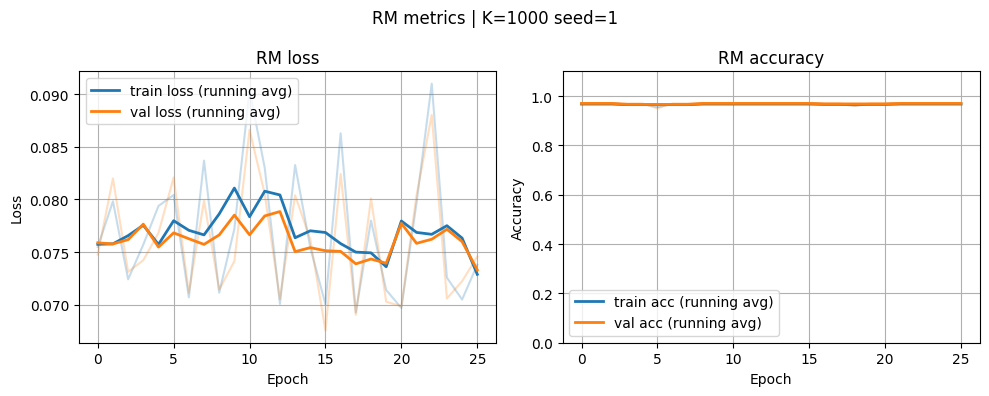

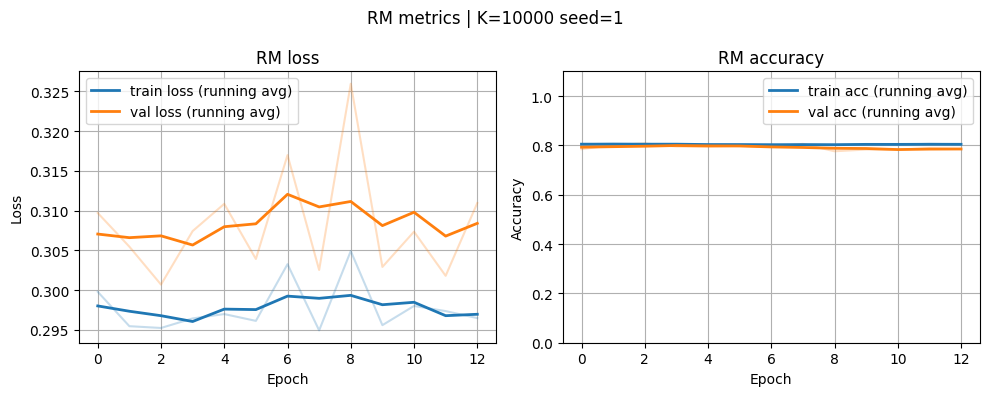

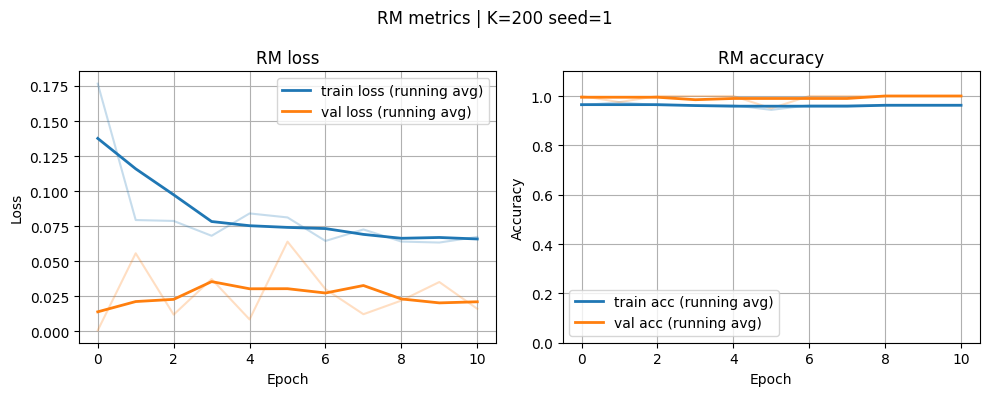

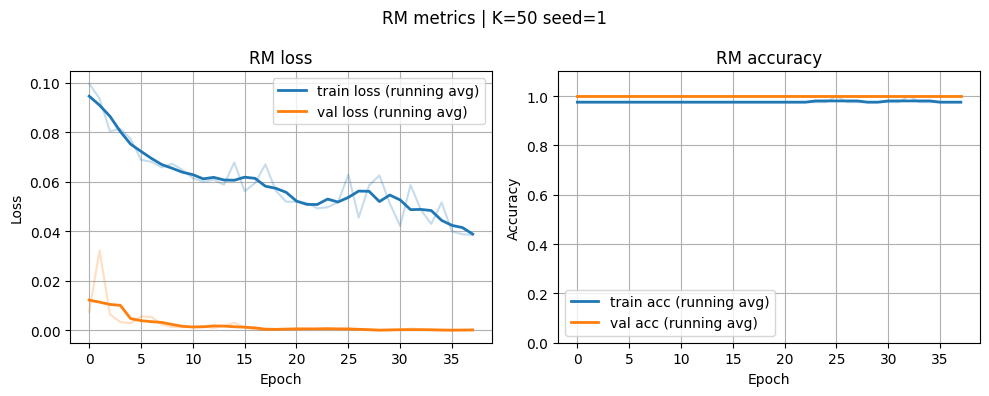

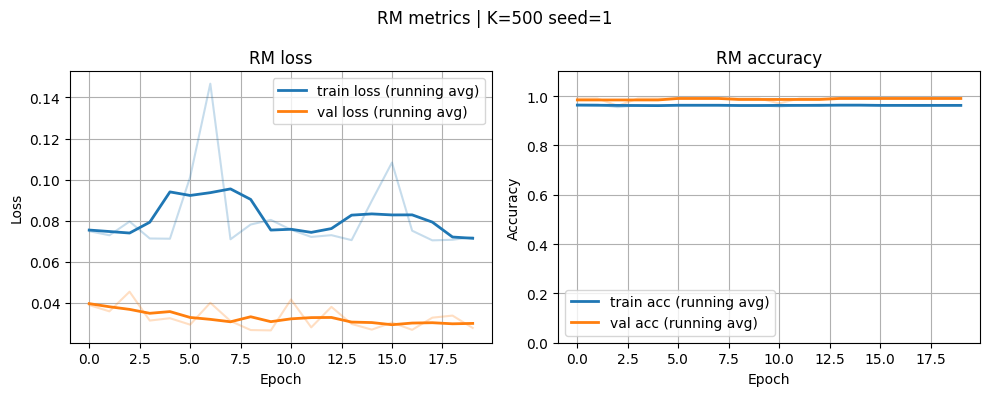

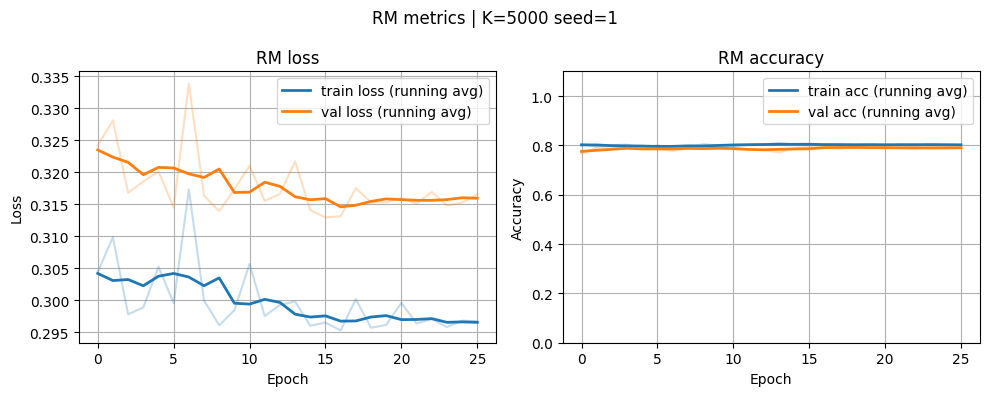

In [114]:
import matplotlib.pyplot as plt


def running_average(values, window=5):
    if len(values) < 2 or window <= 1:
        return list(values)
    arr = np.asarray(values, dtype=float)
    window = min(window, len(arr))
    left_pad = window // 2
    right_pad = window - 1 - left_pad
    padded = np.pad(arr, (left_pad, right_pad), mode="edge")
    weights = np.ones(window, dtype=float) / window
    return np.convolve(padded, weights, mode="valid")


# === Reward model plots ===
for name, history in rm_histories.items():
    meta = rm_meta.get(name, {})
    k = meta.get("K", "?")
    seed = meta.get("seed", "?")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_loss_smooth = running_average(train_loss)
    val_loss_smooth = running_average(val_loss)
    axes[0].plot(train_loss, color="C0", alpha=0.25)
    axes[0].plot(val_loss, color="C1", alpha=0.25)
    axes[0].plot(train_loss_smooth, label="train loss (running avg)", color="C0", linewidth=2.0)
    axes[0].plot(val_loss_smooth, label="val loss (running avg)", color="C1", linewidth=2.0)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("RM loss")
    axes[0].grid(True)
    axes[0].legend()

    train_acc = history["train_acc"]
    val_acc = history["val_acc"]
    train_acc_smooth = running_average(train_acc)
    val_acc_smooth = running_average(val_acc)
    axes[1].plot(train_acc, color="C0", alpha=0.25)
    axes[1].plot(val_acc, color="C1", alpha=0.25)
    axes[1].plot(train_acc_smooth, label="train acc (running avg)", color="C0", linewidth=2.0)
    axes[1].plot(val_acc_smooth, label="val acc (running avg)", color="C1", linewidth=2.0)
    axes[1].set_ylim(0.0, 1.1)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("RM accuracy")
    axes[1].grid(True)
    axes[1].legend()
    fig.suptitle(f"RM metrics | K={k} seed={seed}")
    fig.tight_layout()
    plt.show()

We can now tune the number of epochs depending on the dataset size.

In [ ]:
# === Reward model training ===
rm_models: Dict[str, RewardModel] = {}
rm_histories: Dict[str, Dict[str, List[float]]] = {}
rm_meta: Dict[str, Dict[str, int]] = {}

# Bug fix 1: added entries for new K values {5000, 10000}.
# Early stopping will cut training short if val loss plateaus before these limits.
size_to_epochs = {
    50: 40,
    200: 50,
    500: 60,
    1000: 90,
    5000: 200,
    10000: 300,
}

# Larger datasets have noisier loss landscapes (more batch variance), so they need
# more patience before concluding the val loss has genuinely plateaued.
size_to_patience = {
    50: 10,
    200: 10,
    500: 20,
    1000: 20,
    5000: 30,
    10000: 40,
}

if not dataset_list:
    print("No preference datasets found for", ENV_KEY)
else:
    for dataset in dataset_list:
        rm_hidden = 64 if dataset.k <= 1000 else 256
        reward_model, rm_history = train_reward_model(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            hidden=rm_hidden,
            epochs=size_to_epochs.get(dataset.k, 100),
            patience=size_to_patience.get(dataset.k, 10),
            lambda_reg=0.01,
        )
        bias_val = center_reward_model(reward_model, p1_policy, ENV_ID)
        print(f"  RM centering: subtracted bias {bias_val:.4f} (mean π1 per-step reward)")
        key = dataset.path.name
        rm_models[key] = reward_model
        rm_histories[key] = rm_history
        rm_meta[key] = {"K": dataset.k, "seed": dataset.seed}

RM epoch 1/90 | train loss 0.075 acc 0.967 | val loss 0.075 acc 0.970
RM epoch 2/90 | train loss 0.080 acc 0.967 | val loss 0.082 acc 0.970
RM epoch 3/90 | train loss 0.072 acc 0.967 | val loss 0.073 acc 0.970
RM epoch 4/90 | train loss 0.076 acc 0.967 | val loss 0.074 acc 0.970
RM epoch 5/90 | train loss 0.079 acc 0.967 | val loss 0.077 acc 0.970
RM epoch 6/90 | train loss 0.080 acc 0.955 | val loss 0.082 acc 0.950
RM epoch 7/90 | train loss 0.071 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 8/90 | train loss 0.084 acc 0.967 | val loss 0.080 acc 0.970
RM epoch 9/90 | train loss 0.071 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 10/90 | train loss 0.077 acc 0.967 | val loss 0.074 acc 0.970
RM epoch 11/90 | train loss 0.090 acc 0.967 | val loss 0.087 acc 0.970
RM epoch 12/90 | train loss 0.083 acc 0.967 | val loss 0.081 acc 0.970
RM epoch 13/90 | train loss 0.070 acc 0.967 | val loss 0.071 acc 0.970
RM epoch 14/90 | train loss 0.083 acc 0.967 | val loss 0.080 acc 0.970
RM epoch 15/90 

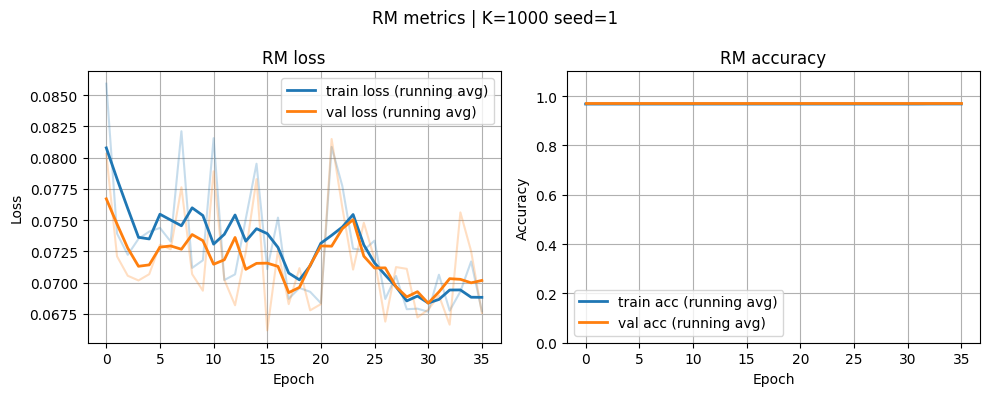

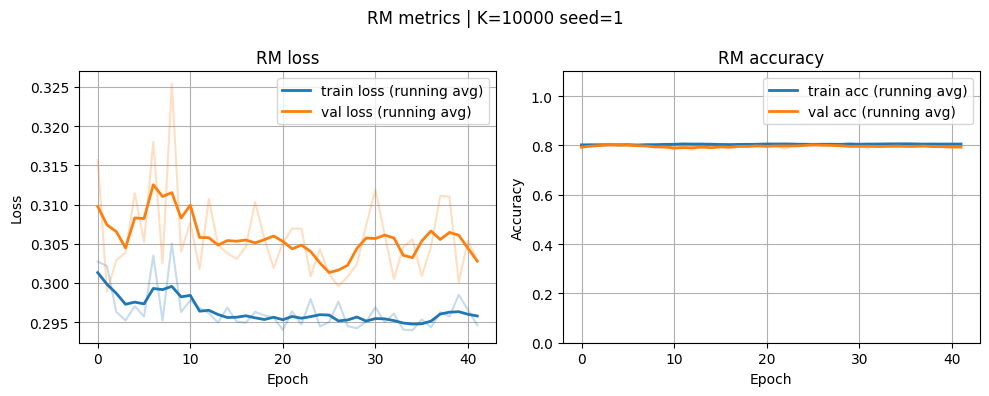

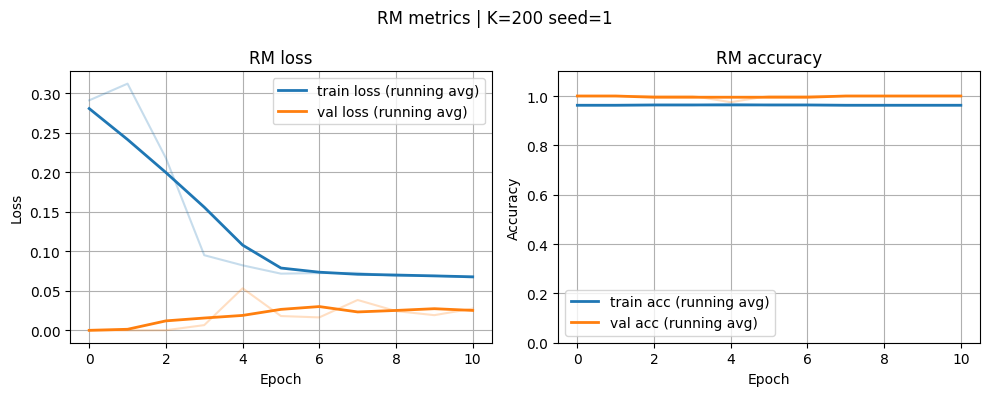

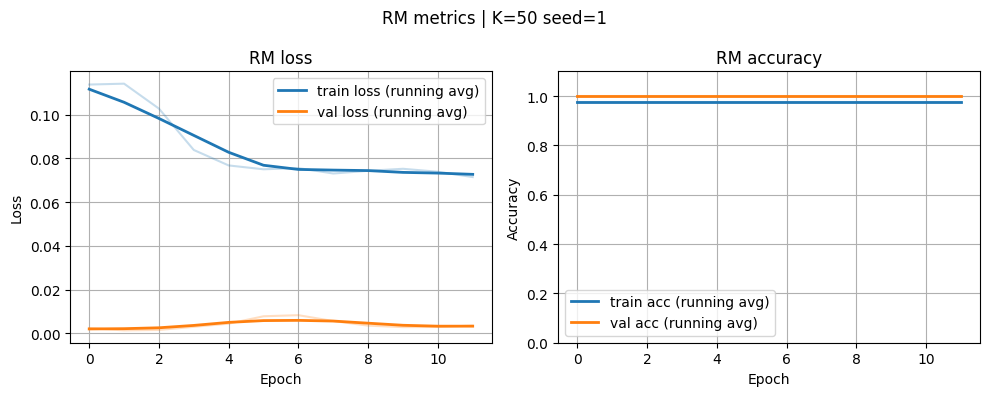

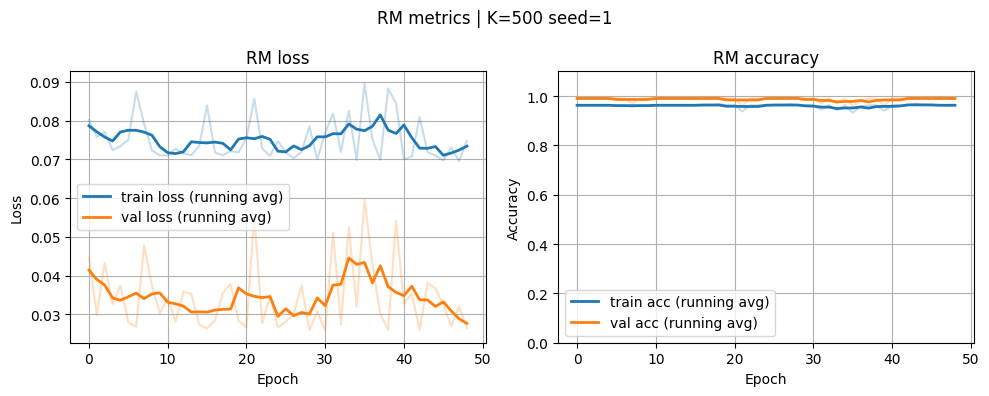

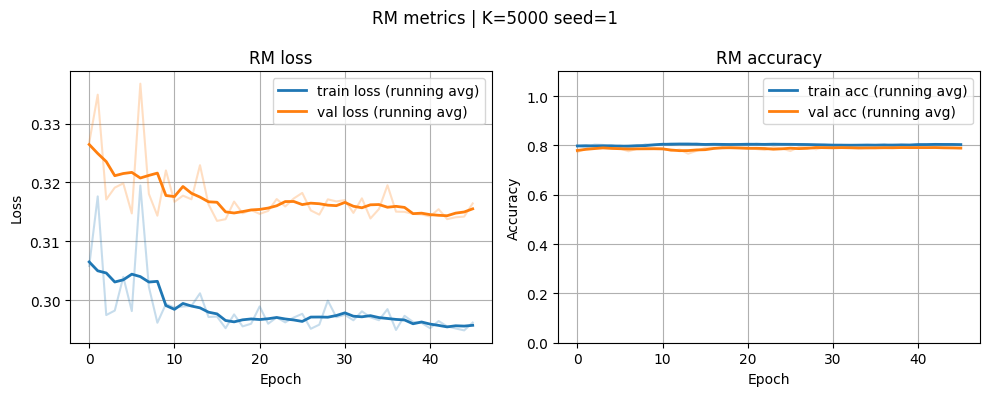

In [ ]:
import matplotlib.pyplot as plt


def running_average(values, window=5):
    if len(values) < 2 or window <= 1:
        return list(values)
    arr = np.asarray(values, dtype=float)
    window = min(window, len(arr))
    left_pad = window // 2
    right_pad = window - 1 - left_pad
    padded = np.pad(arr, (left_pad, right_pad), mode="edge")
    weights = np.ones(window, dtype=float) / window
    return np.convolve(padded, weights, mode="valid")


# === Reward model plots ===
for name, history in rm_histories.items():
    meta = rm_meta.get(name, {})
    k = meta.get("K", "?")
    seed = meta.get("seed", "?")
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    train_loss = history["train_loss"]
    val_loss = history["val_loss"]
    train_loss_smooth = running_average(train_loss)
    val_loss_smooth = running_average(val_loss)
    axes[0].plot(train_loss, color="C0", alpha=0.25)
    axes[0].plot(val_loss, color="C1", alpha=0.25)
    axes[0].plot(train_loss_smooth, label="train loss (running avg)", color="C0", linewidth=2.0)
    axes[0].plot(val_loss_smooth, label="val loss (running avg)", color="C1", linewidth=2.0)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("RM loss")
    axes[0].grid(True)
    axes[0].legend()

    train_acc = history["train_acc"]
    val_acc = history["val_acc"]
    train_acc_smooth = running_average(train_acc)
    val_acc_smooth = running_average(val_acc)
    axes[1].plot(train_acc, color="C0", alpha=0.25)
    axes[1].plot(val_acc, color="C1", alpha=0.25)
    axes[1].plot(train_acc_smooth, label="train acc (running avg)", color="C0", linewidth=2.0)
    axes[1].plot(val_acc_smooth, label="val acc (running avg)", color="C1", linewidth=2.0)
    axes[1].set_ylim(0.0, 1.1)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("RM accuracy")
    axes[1].grid(True)
    axes[1].legend()
    fig.suptitle(f"RM metrics | K={k} seed={seed}")
    fig.tight_layout()
    plt.show()

In [ ]:
# === Save reward models to disk ===
save_dir = OUTPUT_DIR / "reward_models"
save_dir.mkdir(parents=True, exist_ok=True)
meta_path = save_dir / f"rm_meta_{ENV_KEY}.pkl"
import pickle
count = 0
for name, model in rm_models.items():
    path = save_dir / f"{name}.pt"
    torch.save(model.state_dict(), path)
    count += 1
with open(meta_path, "wb") as f:
    pickle.dump(rm_meta, f)
print(f"Saved {count} reward models to {save_dir}")

Saved 6 reward models to outputs/part3/reward_models


In [ ]:
# === Load reward models from disk ===
save_dir = OUTPUT_DIR / "reward_models"
meta_path = save_dir / f"rm_meta_{ENV_KEY}.pkl"
if not save_dir.exists():
    print(f"No save directory found at {save_dir}")
else:
    import pickle
    loaded = {}
    for path in sorted(save_dir.glob(f"{ENV_KEY}_*.pt")):
        name = path.stem
        state = torch.load(path, map_location=DEVICE)
        hidden = state["net.0.weight"].shape[0]  # infer from saved weights
        model = RewardModel(ENV_OBS_DIM, ENV_ACTION_DIM, ENV_CONTINUOUS, hidden=hidden).to(DEVICE)
        model.load_state_dict(state)
        model.eval()
        loaded[name] = model
    if meta_path.exists():
        with open(meta_path, "rb") as f:
            rm_meta = pickle.load(f)
    rm_models = loaded
    print(f"Loaded {len(rm_models)} reward models from {save_dir}")

Loaded 6 reward models from outputs/part3/reward_models


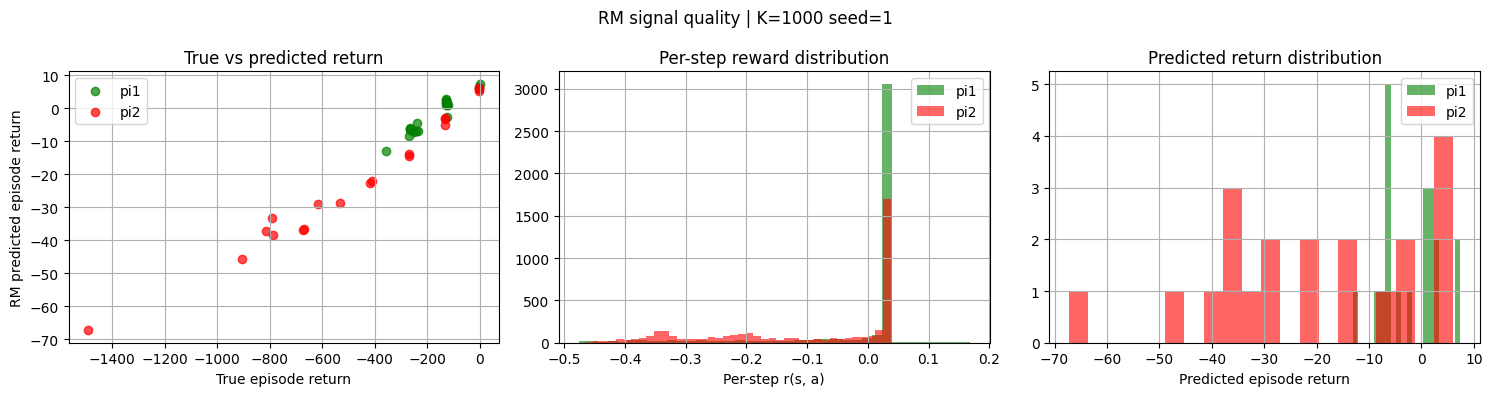

K=1000 | pi1 true=-176.4  pred=-2.042 | pi2 true=-452.4  pred=-20.676 | per-step std=0.1435 | direction OK


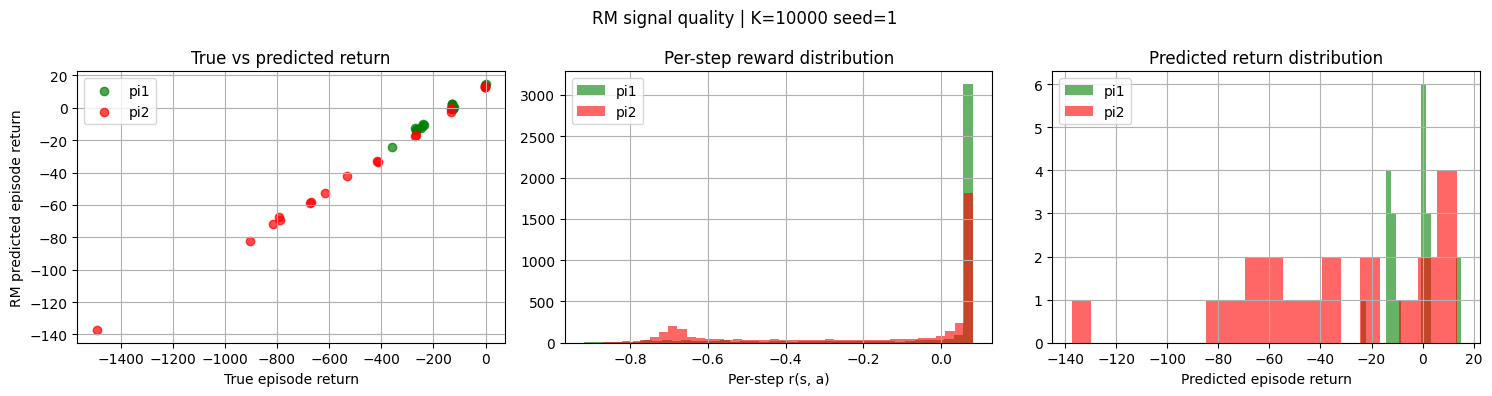

K=10000 | pi1 true=-176.4  pred=-4.221 | pi2 true=-452.4  pred=-34.565 | per-step std=0.2831 | direction OK


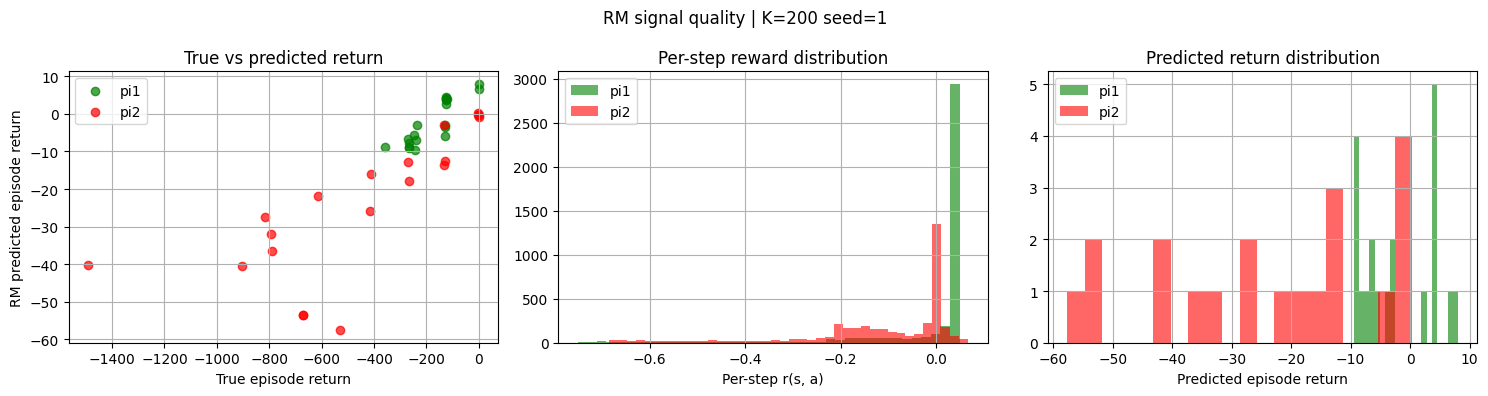

K=200 | pi1 true=-176.4  pred=-2.033 | pi2 true=-452.4  pred=-23.295 | per-step std=0.1559 | direction OK


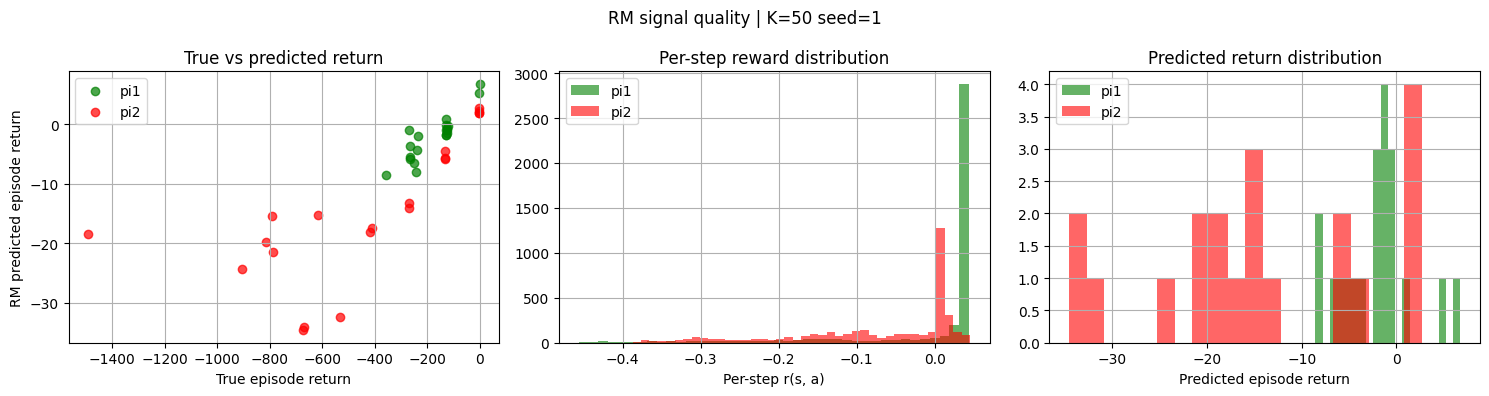

K=50 | pi1 true=-176.4  pred=-2.051 | pi2 true=-452.4  pred=-14.295 | per-step std=0.1087 | direction OK


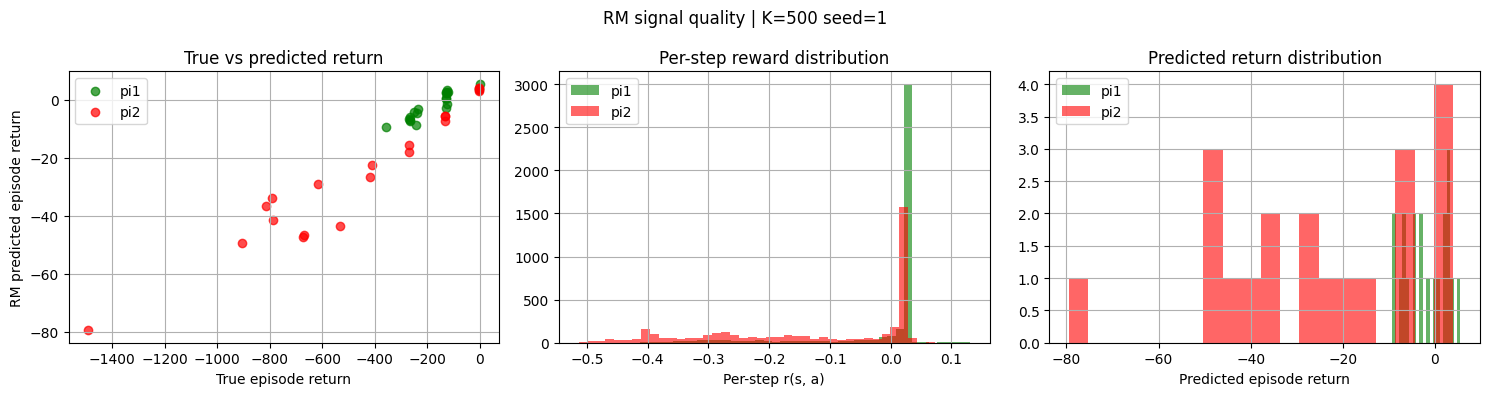

K=500 | pi1 true=-176.4  pred=-1.877 | pi2 true=-452.4  pred=-24.690 | per-step std=0.1450 | direction OK


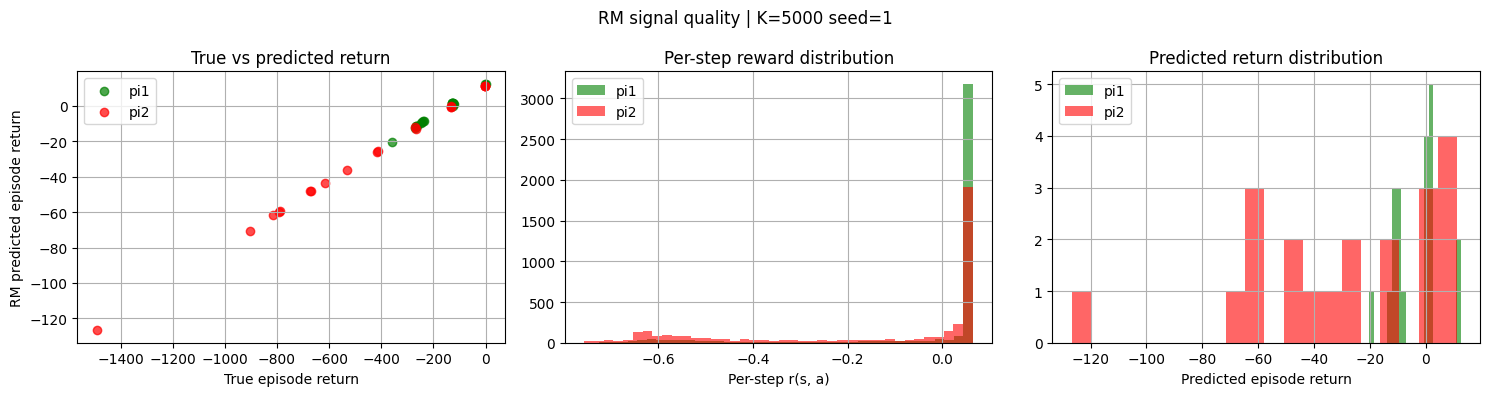

K=5000 | pi1 true=-176.4  pred=-3.438 | pi2 true=-452.4  pred=-29.446 | per-step std=0.2444 | direction OK


In [ ]:
def evaluate_rm_signal(reward_model, env_id, n_episodes=20, seed=99):
    env = gym.make(env_id)
    rng = np.random.default_rng(seed)
    data = {name: {"true": [], "pred": [], "pred_steps": []} for name in ["pi1", "pi2"]}
    for policy, name in [(p1_policy, "pi1"), (p2_policy, "pi2")]:
        for _ in range(n_episodes):
            obs, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
            true_r_sum, pred_r_sum = 0.0, 0.0
            done = False
            while not done:
                action, _ = policy.predict(obs, deterministic=True)
                obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                if ENV_CONTINUOUS:
                    act_t = torch.tensor(np.asarray(action), dtype=torch.float32, device=DEVICE).unsqueeze(0)
                else:
                    act_t = torch.tensor(np.asarray(action), dtype=torch.long, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    pred_r = float(reward_model(obs_t, act_t).cpu().item())
                next_obs, true_r, terminated, truncated, _ = env.step(action)
                true_r_sum += float(true_r)
                pred_r_sum += pred_r
                data[name]["pred_steps"].append(pred_r)
                obs = next_obs
                done = terminated or truncated
            data[name]["true"].append(true_r_sum)
            data[name]["pred"].append(pred_r_sum)
    env.close()
    return data

for rm_name, rm in rm_models.items():
    rm.eval()
    meta = rm_meta.get(rm_name, {})
    k = meta.get("K", "?")
    seed = meta.get("seed", "?")
    data = evaluate_rm_signal(rm, ENV_ID)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"RM signal quality | K={k} seed={seed}")
    # scatter: true vs predicted episode return
    for name, color in [("pi1", "green"), ("pi2", "red")]:
        axes[0].scatter(data[name]["true"], data[name]["pred"], label=name, alpha=0.7, color=color)
    axes[0].set_xlabel("True episode return")
    axes[0].set_ylabel("RM predicted episode return")
    axes[0].set_title("True vs predicted return")
    axes[0].legend()
    axes[0].grid(True)
    # per-step reward distribution (scale check)
    for name, color in [("pi1", "green"), ("pi2", "red")]:
        axes[1].hist(data[name]["pred_steps"], bins=40, alpha=0.6, label=name, color=color)
    axes[1].set_xlabel("Per-step r(s, a)")
    axes[1].set_title("Per-step reward distribution")
    axes[1].legend()
    axes[1].grid(True)
    # predicted return distribution (separation check)
    for name, color in [("pi1", "green"), ("pi2", "red")]:
        axes[2].hist(data[name]["pred"], bins=20, alpha=0.6, label=name, color=color)
    axes[2].set_xlabel("Predicted episode return")
    axes[2].set_title("Predicted return distribution")
    axes[2].legend()
    axes[2].grid(True)
    plt.tight_layout()
    plt.show()
    pi1_pred_mean = np.mean(data["pi1"]["pred"])
    pi2_pred_mean = np.mean(data["pi2"]["pred"])
    all_steps = data["pi1"]["pred_steps"] + data["pi2"]["pred_steps"]
    direction_ok = pi1_pred_mean > pi2_pred_mean
    print(
        f"K={k} | pi1 true={np.mean(data['pi1']['true']):.1f}  pred={pi1_pred_mean:.3f} | "
        f"pi2 true={np.mean(data['pi2']['true']):.1f}  pred={pi2_pred_mean:.3f} | "
        f"per-step std={np.std(all_steps):.4f} | "
        f"direction {'OK' if direction_ok else 'WRONG'}"
    )

## Run PPO-RLHF / DPO experiments

In [ ]:
dpo_results: Dict[int, Dict[str, float]] = {}
dpo_histories: Dict[int, Dict[str, List[float]]] = {}

if not dataset_list:
    print("No datasets available for", ENV_KEY)
else:
    dataset_seeds = [dataset.seed for dataset in dataset_list]
    # Make sure both PPO training and evaluation samples seeds differently from datasets
    ppo_training_seeds = [max(dataset_seeds) + 1 + i for i in range(len(dataset_seeds))]
    eval_seed = max(ppo_training_seeds) + 1
    print(
        f"Starting RLHF DPO loop for {ENV_KEY}: "
        f"{len(dataset_list)} datasets, eval_seed={eval_seed}, "
        f"PPO training seeds={ppo_training_seeds}"
    )
    for i, dataset in enumerate(dataset_list):
        if not dataset.s_pref_list:
            print(f"Skipping {dataset.path.name}: no preference pairs")
            continue
        pref_seed = dataset.seed
        print(
            f"\n[{i + 1}/{len(dataset_list)}] dataset={dataset.path.name} "
            f"K={dataset.k} pref_seed={pref_seed}"
        )
        assert eval_seed != pref_seed, "Eval seed must differ from preference dataset seed"
        print("  training DPO...")
        dpo_policy, dpo_history = train_dpo(
            dataset.s_pref_list,
            dataset.a_pref_list,
            dataset.s_rej_list,
            dataset.a_rej_list,
            eval_seed=eval_seed,
        )
        dpo_mean, dpo_std = eval_policy_true_reward(
            dpo_policy,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        print(f"  DPO done: true reward mean={dpo_mean:.3f} std={dpo_std:.3f}")
        dpo_histories[dataset.k] = dpo_history
        dpo_results[dataset.k] = {
            "env": dataset.env_key,
            "dataset": dataset.path.name,
            "K": dataset.k,
            "seed": pref_seed,
            "dpo_return": dpo_mean,
            "dpo_std": dpo_std,
        }

Starting RLHF DPO loop for pendulum: 4 datasets, eval_seed=6, PPO training seeds=[2, 3, 4, 5]

[1/4] dataset=pendulum_seed1_K1000.pkl K=1000 pref_seed=1
  training DPO...


DPO training:   0%|          | 0/1 [00:00<?, ?epoch/s]

DPO checkpoint at step 19200: true reward -535.365 ± 294.178


DPO checkpoint at step 38400: true reward -652.218 ± 299.648


DPO checkpoint at step 51200: true reward -701.302 ± 297.780


...

DPO checkpoint at step 115200: true reward -951.869 ± 507.766
DPO checkpoint at step 134400: true reward -1012.231 ± 496.685


DPO checkpoint at step 153600: true reward -1037.137 ± 508.342
DPO checkpoint at step 166400: true reward -1059.440 ± 517.051


DPO training: 100%|██████████| 1/1 [00:01<00:00,  1.39s/epoch]

DPO checkpoint at step 185600: true reward -1138.178 ± 482.198
DPO checkpoint at step 198400: true reward -1152.361 ± 487.325
DPO checkpoint at step 200000: true reward -1104.134 ± 537.074


  DPO done: true reward mean=-1104.134 std=537.074


In [ ]:
results = []
ppo_histories: Dict[int, Dict[str, List[float]]] = {}

if not dataset_list:
    print("No datasets available for", ENV_KEY)
else:
    dataset_seeds = [dataset.seed for dataset in dataset_list]
    # Make sure both PPO training and evaluation samples seeds differently from datasets
    ppo_training_seeds = [max(dataset_seeds) + 1 + i for i in range(len(dataset_seeds))]
    eval_seed = max(ppo_training_seeds) + 1
    print(
        f"Starting RLHF PPO loop for {ENV_KEY}: "
        f"{len(dataset_list)} datasets, eval_seed={eval_seed}, "
        f"PPO training seeds={ppo_training_seeds}"
    )
    for i, dataset in enumerate(dataset_list):
        if not dataset.s_pref_list:
            print(f"Skipping {dataset.path.name}: no preference pairs")
            continue
        pref_seed = dataset.seed
        ppo_training_seed = ppo_training_seeds[i]
        print(
            f"\n[{i + 1}/{len(dataset_list)}] dataset={dataset.path.name} "
            f"K={dataset.k} pref_seed={pref_seed} ppo_seed={ppo_training_seed}"
        )
        assert eval_seed != pref_seed \
            and ppo_training_seed != pref_seed \
            and eval_seed != ppo_training_seed, \
            "Eval and PPO training seeds must differ from each other and from preference dataset seed"
        dpo_result = dpo_results.get(dataset.k)
        if dpo_result is None:
            raise ValueError(f"Missing DPO result for K={dataset.k}")
        reward_model = rm_models.get(dataset.path.name)
        if reward_model is None:
            raise ValueError(f"Missing reward model for {dataset.path.name}")
        print("  training PPO-RLHF...")
        ppo_model, ppo_history = train_ppo_with_reward_model(
            ENV_ID,
            reward_model,
            seed=ppo_training_seed,
            eval_seed=eval_seed,
        )
        ppo_mean, ppo_std = eval_policy_true_reward(
            ppo_model,
            ENV_ID,
            EVAL_EPISODES,
            eval_seed=eval_seed,
        )
        print(f"  PPO-RLHF done: true reward mean={ppo_mean:.3f} std={ppo_std:.3f}")
        ppo_histories[dataset.k] = ppo_history
        result = dict(dpo_result)
        result.update({
            "ppo_return": ppo_mean,
            "ppo_std": ppo_std,
        })
        results.append(result)
        print(f"  recorded result for K={dataset.k}")
    if results:
        import pandas as pd
        df = pd.DataFrame(results)
        out_path = OUTPUT_DIR / f"results_{ENV_KEY}.csv"
        df.to_csv(out_path, index=False)
        print(f"Saved {len(results)} rows to {out_path}")
    else:
        print("No results were produced.")

Starting RLHF PPO loop for pendulum: 4 datasets, eval_seed=6, PPO training seeds=[2, 3, 4, 5]

[1/4] dataset=pendulum_seed1_K1000.pkl K=1000 pref_seed=1 ppo_seed=2
  training PPO-RLHF...


PPO-RLHF training:   5%|▍         | 45056/1000000 [00:23<08:09, 1952.61step/s]


KeyboardInterrupt: 

## Plot performance vs K

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


if "df" not in globals():
    result_path = OUTPUT_DIR / f"results_{ENV_KEY}.csv"
    if result_path.exists():
        df = pd.read_csv(result_path)


if "df" in globals() and not df.empty:
    plt.figure(figsize=(8, 4))
    for algo, mean_col, std_col in [
        ("DPO", "dpo_return", "dpo_std"),
        ("PPO-RLHF", "ppo_return", "ppo_std"),
    ]:
        sub = df.groupby("K").agg({mean_col: "mean", std_col: "mean"}).reset_index()
        plt.plot(sub["K"], sub[mean_col], marker="o", label=algo)
        lower = sub[mean_col] - sub[std_col]
        upper = sub[mean_col] + sub[std_col]
        plt.fill_between(sub["K"], lower, upper, alpha=0.2)
    plt.xlabel("K (preference dataset size)")
    plt.ylabel("Average return")
    plt.title(f"{ENV_KEY} performance vs K")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No results available to plot.")

No results available to plot.


C:\Users\brygo\AppData\Local\Temp\ipykernel_61088\2176830458.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title="K")


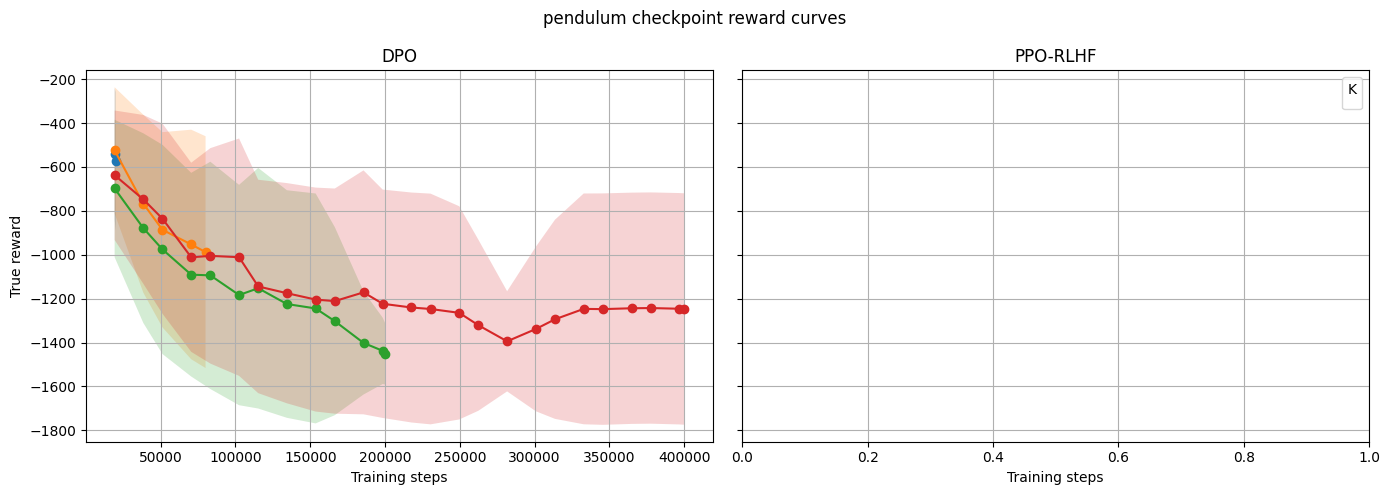

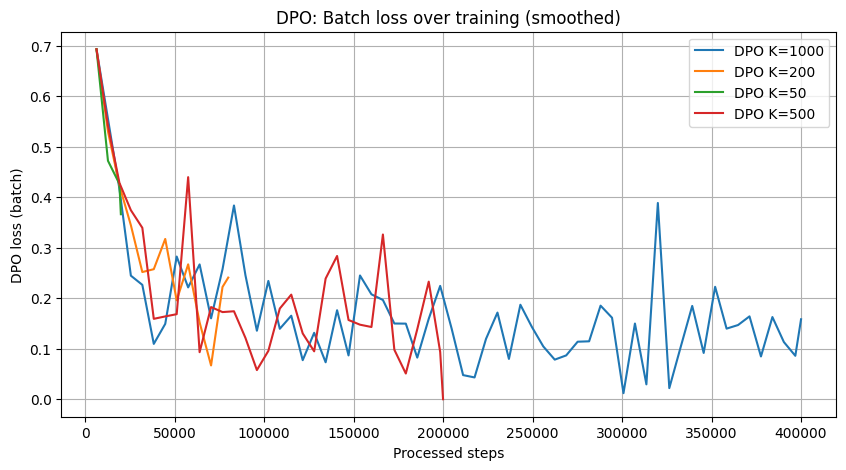

In [ ]:
import matplotlib.pyplot as plt

# === Checkpoint reward curves (DPO / PPO-RLHF) ===
if dpo_histories or ppo_histories:
    ordered_ks = sorted(set(dpo_histories) | set(ppo_histories))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, title, histories in [
        (axes[0], "DPO", dpo_histories),
        (axes[1], "PPO-RLHF", ppo_histories),
    ]:
        for k in ordered_ks:
            history = histories.get(k)
            if not history:
                continue
            steps = history["steps"]
            mean_reward = history["mean_reward"]
            std_reward = history["std_reward"]
            ax.plot(steps, mean_reward, marker="o", label=f"K={k}")
            ax.fill_between(
                steps,
                [m - s for m, s in zip(mean_reward, std_reward)],
                [m + s for m, s in zip(mean_reward, std_reward)],
                alpha=0.2,
            )
        ax.set_title(title)
        ax.set_xlabel("Training steps")
        ax.grid(True)
    axes[0].set_ylabel("True reward")
    axes[1].legend(title="K")
    fig.suptitle(f"{ENV_KEY} checkpoint reward curves")
    fig.tight_layout()
    plt.show()
else:
    print("No checkpoint histories available yet. Run the training cell first.")

# === DPO training loss plots ===
# Plot recorded batch losses from DPO training (one curve per K)
if dpo_histories:
    plt.figure(figsize=(10, 5))
    for k, history in dpo_histories.items():
        losses = history.get("dpo_losses", [])
        loss_steps = history.get("dpo_loss_steps", [])
        if not losses or not loss_steps:
            continue
        # smooth for visibility
        try:
            losses_smooth = running_average(losses)
        except Exception:
            losses_smooth = losses
        plt.plot(loss_steps[:len(losses_smooth)], losses_smooth, label=f"DPO K={k}")
    plt.xlabel("Processed steps")
    plt.ylabel("DPO loss (batch)")
    plt.title("DPO: Batch loss over training (smoothed)")
    plt.grid(True)
    plt.legend(loc="best")
    plt.show()
else:
    print("No DPO histories available to plot. Run DPO training first.")